j'importe mon dataset et je visualise les info

In [1]:
import pandas as pd

df = pd.read_csv(
    "../../data/extracted/dvf/ValeursFoncieres-2025.txt",
    sep="|",
    low_memory=False,
    nrows=100000
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Identifiant de document     0 non-null       float64
 1   Reference document          0 non-null       float64
 2   1 Articles CGI              0 non-null       float64
 3   2 Articles CGI              0 non-null       float64
 4   3 Articles CGI              0 non-null       float64
 5   4 Articles CGI              0 non-null       float64
 6   5 Articles CGI              0 non-null       float64
 7   No disposition              100000 non-null  int64  
 8   Date mutation               100000 non-null  object 
 9   Nature mutation             100000 non-null  object 
 10  Valeur fonciere             99341 non-null   object 
 11  No voie                     54771 non-null   float64
 12  B/T/Q                       3154 non-null    object 
 13  Type de voie   

In [2]:
df[[
    "Valeur fonciere",
    "Surface reelle bati",
    "Nombre pieces principales",
    "Surface terrain"
]].isna().sum()

Valeur fonciere                659
Surface reelle bati          47099
Nombre pieces principales    47099
Surface terrain              17148
dtype: int64

In [3]:
df["Type local"].value_counts()

Type local
Dépendance                                  24231
Maison                                      18181
Appartement                                  7910
Local industriel. commercial ou assimilé     2658
Name: count, dtype: int64

In [4]:
df["Nature mutation"].value_counts()

Nature mutation
Vente                                 96374
Vente en l'état futur d'achèvement     1895
Echange                                1351
Adjudication                            196
Vente terrain à bâtir                   173
Expropriation                            11
Name: count, dtype: int64

In [5]:
df.isna().sum().sort_values(ascending=False).head(20)

Identifiant de document       100000
Reference document            100000
1 Articles CGI                100000
2 Articles CGI                100000
3 Articles CGI                100000
4 Articles CGI                100000
5 Articles CGI                100000
Identifiant local             100000
Surface Carrez du 5eme lot     99984
Surface Carrez du 4eme lot     99950
No Volume                      99861
5eme lot                       99846
Surface Carrez du 3eme lot     99737
4eme lot                       99607
3eme lot                       98718
Surface Carrez du 2eme lot     98440
Nature culture speciale        97588
Prefixe de section             97398
B/T/Q                          96846
Surface Carrez du 1er lot      96146
dtype: int64

je recupere uniquement les nature mutation (vente) et type local (maison, appart)

In [6]:
df_filtre = df[
    (df["Nature mutation"] == "Vente")
    &
    (
        df["Type local"].isin(
            ["Maison", "Appartement"]
        )
    )
]

print(df_filtre.shape)

(25904, 43)


In [7]:
df_filtre[[
    "Valeur fonciere",
    "Surface reelle bati",
    "Nombre pieces principales"
]].isna().sum()

Valeur fonciere              98
Surface reelle bati           0
Nombre pieces principales     0
dtype: int64

je cree mon dataframe clean pour faire tout le netoyage

In [8]:
colonnes_utiles = [
    "Date mutation",
    "Nature mutation",
    "Valeur fonciere",
    "Code postal",
    "Commune",
    "Code departement",
    "Code commune",
    "Type local",
    "Surface reelle bati",
    "Nombre pieces principales",
    "Surface terrain"
]

df_clean = df_filtre[colonnes_utiles].copy()

In [9]:
df_clean.head()

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Code departement,Code commune,Type local,Surface reelle bati,Nombre pieces principales,Surface terrain
2,07/01/2025,Vente,"468000,00",1550.0,FARGES,1,158,Maison,111.0,5.0,133.0
5,06/01/2025,Vente,"180000,00",1200.0,MONTANGES,1,257,Appartement,87.0,4.0,76.0
9,06/01/2025,Vente,"490000,00",1310.0,BUELLAS,1,65,Maison,190.0,6.0,500.0
14,06/01/2025,Vente,"490000,00",1310.0,BUELLAS,1,65,Maison,190.0,6.0,2452.0
18,09/01/2025,Vente,"183000,00",1170.0,GEX,1,173,Appartement,35.0,2.0,NaN


In [10]:
df_clean.isna().sum()

Date mutation                   0
Nature mutation                 0
Valeur fonciere                98
Code postal                     0
Commune                         0
Code departement                0
Code commune                    0
Type local                      0
Surface reelle bati             0
Nombre pieces principales       0
Surface terrain              5758
dtype: int64

In [11]:
df_clean["Valeur fonciere"].head()

2     468000,00
5     180000,00
9     490000,00
14    490000,00
18    183000,00
Name: Valeur fonciere, dtype: object

je remplace toutes les valeurs fonciere qui ont la virgule part le .

In [12]:
df_clean["Valeur fonciere"] = (
    df_clean["Valeur fonciere"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

je convertir la date en datetime

In [13]:
df_clean["Date mutation"] = pd.to_datetime(
    df_clean["Date mutation"],
    dayfirst=True
)

les 98 valeur manquantes dans valeures fonciere je supprime car elle est negligeable

In [14]:
df_clean = df_clean.dropna(subset=["Valeur fonciere"])

In [15]:
df_clean.isnull().sum()

Date mutation                   0
Nature mutation                 0
Valeur fonciere                 0
Code postal                     0
Commune                         0
Code departement                0
Code commune                    0
Type local                      0
Surface reelle bati             0
Nombre pieces principales       0
Surface terrain              5678
dtype: int64

je visualise toutes les valeurs manquantes dans surfaces terrain pour voir comment c'est repartir paert type local 

In [16]:
df_clean.groupby("Type local")["Surface terrain"].apply(lambda x: x.isnull().sum())

Type local
Appartement    5226
Maison          452
Name: Surface terrain, dtype: int64

In [17]:
df_clean.dtypes

Date mutation                datetime64[ns]
Nature mutation                      object
Valeur fonciere                     float64
Code postal                         float64
Commune                              object
Code departement                      int64
Code commune                          int64
Type local                           object
Surface reelle bati                 float64
Nombre pieces principales           float64
Surface terrain                     float64
dtype: object

In [18]:
df_clean["Valeur fonciere"].head()

2     468000.0
5     180000.0
9     490000.0
14    490000.0
18    183000.0
Name: Valeur fonciere, dtype: float64

la je fait une analyse pour voir les outlier et on peut constater que on a part exemple des surface bati a 1m2

In [19]:
df_clean["Valeur fonciere"].describe()

count    2.580600e+04
mean     3.000706e+05
std      1.187169e+06
min      1.000000e+00
25%      8.900000e+04
50%      1.550000e+05
75%      2.560000e+05
max      2.400000e+07
Name: Valeur fonciere, dtype: float64

In [20]:
df_clean["Surface reelle bati"].describe()

count    25806.000000
mean        91.203441
std         44.635120
min          1.000000
25%         63.000000
50%         85.000000
75%        111.000000
max        745.000000
Name: Surface reelle bati, dtype: float64

In [21]:
df_clean["Nombre pieces principales"].describe()

count    25806.000000
mean         3.759552
std          1.571015
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         25.000000
Name: Nombre pieces principales, dtype: float64

In [22]:
df_clean["Surface terrain"].describe()

count    20128.000000
mean       962.970986
std       2861.154196
min          0.000000
25%        249.000000
50%        502.000000
75%        879.000000
max      92451.000000
Name: Surface terrain, dtype: float64

la j'ai choisi un seuil pour lesquels on peut considerer comme valeur aberante et je quantifie

In [23]:
(df_clean["Valeur fonciere"] <= 1000).sum()

np.int64(104)

In [24]:
(df_clean["Surface reelle bati"] <= 5).sum()

np.int64(13)

In [25]:
(df_clean["Nombre pieces principales"] == 0).sum()

np.int64(48)

la je fais une visualisation

In [26]:
df_clean[df_clean["Valeur fonciere"] <= 1000].head(10)

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Code departement,Code commune,Type local,Surface reelle bati,Nombre pieces principales,Surface terrain
1665,2025-01-17,Vente,55.0,1430.0,ST-MARTIN-DU-FRESNE,1,373,Maison,147.0,6.0,55.0
2282,2025-01-30,Vente,500.0,1000.0,BOURG-EN-BRESSE,1,53,Appartement,83.0,4.0,NaN
8860,2025-03-19,Vente,80.0,1700.0,NEYRON,1,275,Maison,149.0,5.0,1071.0
10188,2025-04-11,Vente,1.0,1330.0,VILLARS-LES-DOMBES,1,443,Maison,90.0,2.0,7.0
14001,2025-05-23,Vente,500.0,1130.0,NANTUA,1,269,Appartement,98.0,3.0,NaN
16843,2025-06-19,Vente,1.0,1220.0,DIVONNE-LES-BAINS,1,143,Appartement,60.0,2.0,NaN
18958,2025-06-23,Vente,500.0,1000.0,BOURG-EN-BRESSE,1,53,Appartement,96.0,4.0,NaN
19050,2025-07-01,Vente,1.0,1350.0,CRESSIN-ROCHEFORT,1,133,Maison,94.0,4.0,1.0
23948,2025-07-21,Vente,1.0,1250.0,JOURNANS,1,197,Maison,80.0,4.0,94.0
27072,2025-09-24,Vente,240.0,1200.0,VALSERHONE,1,33,Maison,160.0,4.0,12.0


In [27]:
df_clean[df_clean["Surface reelle bati"] <= 5].head(10)

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Code departement,Code commune,Type local,Surface reelle bati,Nombre pieces principales,Surface terrain
1760,2025-01-09,Vente,152900.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
2680,2025-01-28,Vente,118000.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
19012,2025-06-30,Vente,94500.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
20875,2025-07-23,Vente,970000.0,1150.0,LAGNIEU,1,202,Appartement,1.0,1.0,NaN
24921,2025-08-28,Vente,130000.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
27222,2025-09-01,Vente,95000.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
34312,2025-11-21,Vente,131500.0,1700.0,MIRIBEL,1,249,Appartement,2.0,0.0,NaN
45836,2025-02-18,Vente,115000.0,2120.0,GUISE,2,361,Maison,1.0,1.0,NaN
53741,2025-06-05,Vente,60000.0,2300.0,CHAUNY,2,173,Maison,2.0,0.0,72.0
67221,2025-10-14,Vente,420000.0,2400.0,CHATEAU THIERRY,2,168,Appartement,2.0,0.0,NaN


In [28]:
df_clean[df_clean["Nombre pieces principales"] == 0].head(10)

,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Code departement,Code commune,Type local,Surface reelle bati,Nombre pieces principales,Surface terrain
1760,2025-01-09,Vente,152900.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
2680,2025-01-28,Vente,118000.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
15715,2025-06-04,Vente,52000.0,1000.0,BOURG-EN-BRESSE,1,53,Appartement,16.0,0.0,NaN
19012,2025-06-30,Vente,94500.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
24330,2025-08-14,Vente,385000.0,1170.0,CESSY,1,71,Appartement,30.0,0.0,283.0
24921,2025-08-28,Vente,130000.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
27222,2025-09-01,Vente,95000.0,1700.0,SAINT-MAURICE-DE-BEYNOST,1,376,Appartement,1.0,0.0,NaN
27293,2025-09-18,Vente,353000.0,1600.0,TREVOUX,1,427,Appartement,60.0,0.0,NaN
33863,2025-10-30,Vente,60000.0,1851.0,MARBOZ,1,232,Maison,37.0,0.0,3150.0
34312,2025-11-21,Vente,131500.0,1700.0,MIRIBEL,1,249,Appartement,2.0,0.0,NaN


ici je recupere uniquement les valeur fonciere > 1000 et surface bati >5 et pour les type de logement qui sont a 0 je ne supprime pas car on peut considerer ca comme des studio

In [29]:
df_clean = df_clean[df_clean["Valeur fonciere"] > 1000]

In [30]:
df_clean = df_clean[df_clean["Surface reelle bati"] > 5]

In [31]:
print(df_clean.shape)

(25689, 11)


apres avoir recuperer j'ajoute une colonne prix_m2 pour visualiser le prix par m2

In [32]:
df_clean["prix_m2"] = (
    df_clean["Valeur fonciere"]
    /
    df_clean["Surface reelle bati"]
)

ici je fait une description et on peut encore voir qu'on retrouve des valeur aberantes comme par exemple le prix du m2 a 9 euro

In [33]:
df_clean["prix_m2"].describe()

count     25689.000000
mean       3748.689369
std       14127.014738
min           9.375000
25%        1159.420290
50%        1800.000000
75%        2829.268293
max      400000.000000
Name: prix_m2, dtype: float64

je visuale les appartement les plus cheres pour voir ou c'est situer et on constate que ils sont des des zonnes ou les prix coute extrement chere



In [34]:
df_clean.nlargest(
    10,
    "prix_m2"
)[[
    "Valeur fonciere",
    "Surface reelle bati",
    "Type local",
    "Commune",
    "prix_m2"
]]

,Valeur fonciere,Surface reelle bati,Type local,Commune,prix_m2
37456,24000000.0,60.0,Appartement,VALSERHONE,400000.000000
37457,24000000.0,71.0,Appartement,VALSERHONE,338028.169014
41803,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41806,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41807,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41811,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41812,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41817,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41818,15667000.0,74.0,Maison,BELIGNEUX,211716.216216
41819,15667000.0,74.0,Maison,BELIGNEUX,211716.216216


In [35]:
df_clean.nsmallest(
    10,
    "prix_m2"
)[[
    "Valeur fonciere",
    "Surface reelle bati",
    "Type local",
    "Commune",
    "prix_m2"
]]

,Valeur fonciere,Surface reelle bati,Type local,Commune,prix_m2
81359,1350.0,144.0,Maison,ETROUSSAT,9.375000
82083,3200.0,209.0,Maison,CREUZIER-LE-VIEUX,15.311005
82084,3200.0,209.0,Maison,CREUZIER-LE-VIEUX,15.311005
93440,1500.0,91.0,Maison,MAZERIER,16.483516
5161,1800.0,105.0,Maison,VERNOUX,17.142857
5162,1800.0,105.0,Maison,VERNOUX,17.142857
57842,1850.0,84.0,Maison,CLAIRFONTAINE,22.023810
95475,2000.0,90.0,Maison,LE DONJON,22.222222
76116,5000.0,221.0,Maison,VICHY,22.624434
47389,2000.0,84.0,Maison,BOHAIN-EN-VERMANDOIS,23.809524


ici je vais calculer l'iqr pour detecter automatiquement les prix trop eloigné du marcher et on peut constater que tout les bien donc le prix_m2 est supp a 5334 euro est considerer comme atypique par rapport au marché

In [36]:
Q1 = df_clean["prix_m2"].quantile(0.25)
Q3 = df_clean["prix_m2"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Borne inf :", borne_inf)
print("Borne sup :", borne_sup)

Q1 : 1159.4202898550725
Q3 : 2829.268292682927
IQR : 1669.8480028278545
Borne inf : -1345.3517143867093
Borne sup : 5334.040296924709


la je calcule le nombre de bien qu'on retrouve dans le dataset et son pourcentage et on put voir qu'il y'a 2139 bien et sont extrement au dessus du marcher donc 8%

In [37]:
outliers_prix_m2 = (
    df_clean["prix_m2"] > borne_sup
).sum()

print(outliers_prix_m2)

2139


In [38]:
outliers_pct = (
    outliers_prix_m2 / len(df_clean)
) * 100

print(outliers_pct)

8.326521079061076


ici je visulaise les communes ou on retrouve ces biens et on peut voir qu'il sont situé dzns les fontrière suisse et pays de GEX (ain) Or cette zone est connue pour avoir des prix immobiliers extrêmement élevés à cause des travailleurs frontaliers de Genève.

In [39]:
df_clean[
    df_clean["prix_m2"] > borne_sup
]["Commune"].value_counts().head(20)

Commune
DIVONNE-LES-BAINS    182
VICHY                172
BELIGNEUX            125
SAINT QUENTIN        120
GEX                  117
FERNEY-VOLTAIRE       82
PREVESSIN-MOENS       74
MONTLUCON             72
ST-GENIS-POUILLY      54
ORNEX                 47
VILLERS-COTTERETS     46
CESSY                 38
OYONNAX               38
GAUCHY                37
BOURG-EN-BRESSE       35
MOULINS               34
VALSERHONE            34
THOIRY                30
CHATEAU THIERRY       29
JASSANS-RIOTTIER      27
Name: count, dtype: int64

ici je regarde les percentiles enfin de voir ou commencent reellement les valeurs extremes et on peut constater que entre 99% et 99.5% on a une forte augmentation des prix

In [40]:
df_clean["prix_m2"].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.900      4921.123321
0.950      7028.273810
0.990     38353.333333
0.995    136234.782609
0.999    208893.333333
Name: prix_m2, dtype: float64

et pour ne pas supprimer les 8,3% detecter par l'iqr je vais juste copier mes donnée dzns un nouveau dataframe df_ml pour faire du ml

In [41]:
seuil_99 = df_clean["prix_m2"].quantile(0.99)

In [42]:
(
    df_clean["prix_m2"] > seuil_99
).sum()

np.int64(257)

In [43]:
df_ml = df_clean[
    df_clean["prix_m2"] <= seuil_99
].copy()

In [44]:
df_ml["prix_m2"].describe()

count    25432.000000
mean      2519.275533
std       3042.403963
min          9.375000
25%       1152.564165
50%       1785.714286
75%       2783.091311
max      38333.333333
Name: prix_m2, dtype: float64

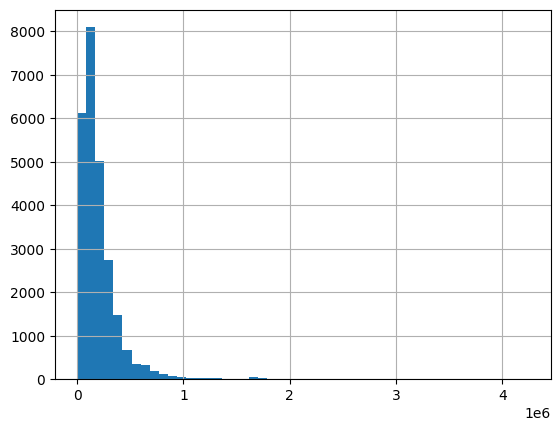

In [45]:
import matplotlib.pyplot as plt

df_ml["Valeur fonciere"].hist(
    bins=50
)

plt.show()

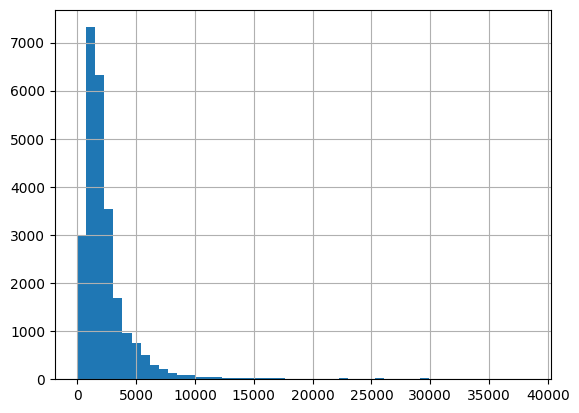

In [46]:
df_ml["prix_m2"].hist(
    bins=50
)

plt.show()

In [47]:
df_ml["Type local"].value_counts()

Type local
Maison         17905
Appartement     7527
Name: count, dtype: int64

In [48]:
df_ml["annee"] = df_ml["Date mutation"].dt.year

df_ml["annee"].value_counts().sort_index()

annee
2025    25432
Name: count, dtype: int64